# Quantum data example in Kappen (2018)
This notebook reproduces the example in Section 4 of [Kappen](https://arxiv.org/abs/1803.11278)

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))  # go up two levels (from numerics to PauliSampling.jl)

  Activating project at `~/Desktop/PauliSampling.jl`


In [2]:
# # Ensure packages are installed
# for pkg in [
#     "PauliPropagation", "Plots", "LinearAlgebra", "ProgressMeter", "Distributions",
#     "Random", "Optimisers", "ReverseDiff", "MAT", "BenchmarkTools", "IterTools", "StatsBase", "LaTeXStrings", "Measures"
# ]
#     Pkg.add(pkg)
# end

In [3]:
# Load all packages
using PauliSampling, PauliPropagation, Plots, LinearAlgebra, ProgressMeter, Statistics, Printf, Distributions, Random, Optimisers, ReverseDiff, MAT, BenchmarkTools, IterTools, StatsBase, LaTeXStrings, Measures

In [4]:
# define number of sites == number of qubits (each site is a 2-level system)
n = 6 ## change this to 10 to reproduce the paper results

6

## Target state

The quantum state we set up to learn using a QBM is a thermal state (for three different temperatures) from the Hamiltonian of the 1D Heisenberg model with nearest-neighbors interactions, isotropic couplings and zero single-site fields. We report here the full Eq. (13) of the [paper](https://arxiv.org/abs/1803.11278):
\begin{equation}
H = \sum_{i=1}^{n} \sum_{k = x, y, z} w_i^{k} \sigma_i^{k}
    + \sum_{i=1}^{n} \sum_{j > i}^{n} \sum_{k = x, y, z} w_{ij}^{k} \sigma_i^{k} \sigma_j^{k},
\end{equation}
where $\sigma_j^{k}$ are Pauli operators on site $j$ and $n$ is the total number of sites.

The target state is generated with the Hamiltonian where
$$
w_{ij}^{x,y,z} = 1 \text{ for nearest neighbors,} \quad 
w_{ij}^{x,y,z} = 0 \text{ otherwise, and } w_i^{k} = 0.
$$


### Hamiltonian 
For this example, we work under the (simplifying) assumption that each spin direction will have a separate parameter, but that the interaction in a fixed spin direction is isotropic along the spin chain of 
sites (we also include periodic boundary conditions). This amounts to the Hamiltonian of the `XYZ` Heisenberg model, but when the `x`, `y`, and `z` couplings are the same, then it is the `XXX` Heisenberg model:

In [5]:
# Fix the parameters of the hamiltonian:
# - 3 parameters for the nearest-neighbors terms
# - 3 parameters for the single-site fields
target_wij_xyz = (1.0, 1.0, 1.0)
target_wi_xyz = (0.0, 0.0, 0.0)
@printf("Spin interaction used to create target state: %s\n", target_wij_xyz)
@printf("Field value used to create target state: %s\n", target_wi_xyz)

Spin interaction used to create target state: (1.0, 1.0, 1.0)
Field value used to create target state: (0.0, 0.0, 0.0)


In [6]:
j_target = 4 .* target_wij_xyz
b_target = 2 .* target_wi_xyz
params_target = HamiltonianParams(n; wi_xyz=b_target, wij_xyz=j_target)
# target_xxx = makehamiltonian(n; wi_xyz=b, wij_xyz=j, periodic=true)
target_xxx = makehamiltonian(params_target; connectivity=:nearest, periodic=true)

18-element Vector{PauliString}:
 PauliString(nqubits: 6, 1.0 * XXIIII)
 PauliString(nqubits: 6, 1.0 * YYIIII)
 PauliString(nqubits: 6, 1.0 * ZZIIII)
 PauliString(nqubits: 6, 1.0 * IXXIII)
 PauliString(nqubits: 6, 1.0 * IYYIII)
 PauliString(nqubits: 6, 1.0 * IZZIII)
 PauliString(nqubits: 6, 1.0 * IIXXII)
 PauliString(nqubits: 6, 1.0 * IIYYII)
 PauliString(nqubits: 6, 1.0 * IIZZII)
 PauliString(nqubits: 6, 1.0 * IIIXXI)
 PauliString(nqubits: 6, 1.0 * IIIYYI)
 PauliString(nqubits: 6, 1.0 * IIIZZI)
 PauliString(nqubits: 6, 1.0 * IIIIXX)
 PauliString(nqubits: 6, 1.0 * IIIIYY)
 PauliString(nqubits: 6, 1.0 * IIIIZZ)
 PauliString(nqubits: 6, 1.0 * XIIIIX)
 PauliString(nqubits: 6, 1.0 * YIIIIY)
 PauliString(nqubits: 6, 1.0 * ZIIIIZ)

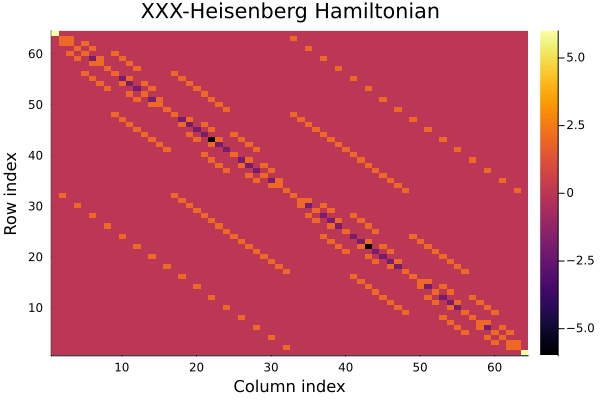

In [7]:
target_xxx_matrix = paulistringtomatrix(target_xxx)

heatmap(reverse(real(target_xxx_matrix); dims=1),
        xlabel="Column index",
        ylabel="Row index",
        title="XXX-Heisenberg Hamiltonian"
        )

### Density matrix

The paper generates a density matrix from the `XXX ` Hamiltonian at 3 different temperatures $T = 1/\beta$
, with $\beta =1,2,∞$

In [8]:
targert_circuit, θ = paulistringtocircuit(target_xxx)
num_layers = 100
max_weight = n
min_abs_coeff = 1e-20;

In [9]:
target_beta1 = 1.0

target_eta_beta1 = makethermalstate(n, targert_circuit, θ, num_layers;
                                  beta=target_beta1, max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)

target_eta_beta1_matrix = paulistringtomatrix(target_eta_beta1);

In [10]:
target_beta2 = 2.0

target_eta_beta2 = makethermalstate(n, targert_circuit, θ, num_layers;
                                  beta=target_beta2, max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)

target_eta_beta2_matrix = paulistringtomatrix(target_eta_beta2);

In [11]:
target_beta∞ = 60.

target_eta_beta∞ = makethermalstate(n, targert_circuit, θ, num_layers;
                                  beta=target_beta∞, max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)

target_eta_beta∞_matrix = paulistringtomatrix(target_eta_beta∞);

## Quantum Boltzmann Machine model

Following the paper we now define the QBM based on the same `XYZ` Heisenberg Hamiltonian used to define the target state. We let the 3 parameters for each spin direction to have arbitrary values.

In [12]:
# parameters to learn. Set initial values at random
rng = MersenneTwister()  
j = Tuple(randn(rng, 3))        
b = Tuple(randn(rng, 3))
@printf("Spin interaction: %s\n", j)
@printf("Field value: %s\n", b)

Spin interaction: (1.180463990502546, -2.5686976955015717, 1.1443533239964205)
Field value: (1.1237218204889177, -0.05535211577435482, -0.6154452833728254)


In [13]:
params = HamiltonianParams(n; wi_xyz=b, wij_xyz=j)

qbm_xyz = makehamiltonian(params; connectivity=:nearest, periodic=true)


36-element Vector{PauliString}:
 PauliString(nqubits: 6, 0.56186 * XIIIII)
 PauliString(nqubits: 6, -0.027676 * YIIIII)
 PauliString(nqubits: 6, -0.30772 * ZIIIII)
 PauliString(nqubits: 6, 0.56186 * IXIIII)
 PauliString(nqubits: 6, -0.027676 * IYIIII)
 PauliString(nqubits: 6, -0.30772 * IZIIII)
 PauliString(nqubits: 6, 0.56186 * IIXIII)
 PauliString(nqubits: 6, -0.027676 * IIYIII)
 PauliString(nqubits: 6, -0.30772 * IIZIII)
 PauliString(nqubits: 6, 0.56186 * IIIXII)
 ⋮
 PauliString(nqubits: 6, 0.29512 * IIIXXI)
 PauliString(nqubits: 6, -0.64217 * IIIYYI)
 PauliString(nqubits: 6, 0.28609 * IIIZZI)
 PauliString(nqubits: 6, 0.29512 * IIIIXX)
 PauliString(nqubits: 6, -0.64217 * IIIIYY)
 PauliString(nqubits: 6, 0.28609 * IIIIZZ)
 PauliString(nqubits: 6, 0.29512 * XIIIIX)
 PauliString(nqubits: 6, -0.64217 * YIIIIY)
 PauliString(nqubits: 6, 0.28609 * ZIIIIZ)

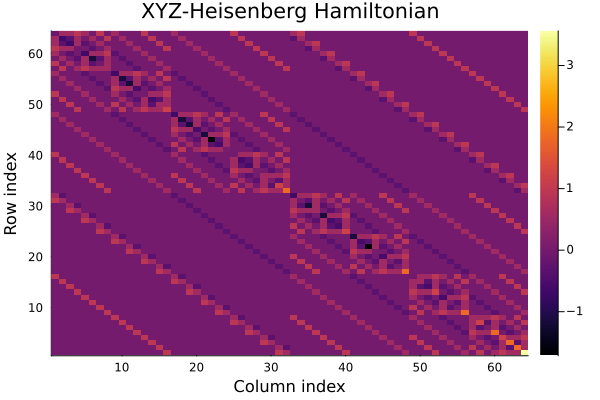

In [14]:
qbm_xyz_matrix = paulistringtomatrix(qbm_xyz)

heatmap(reverse(real(qbm_xyz_matrix); dims=1),
        xlabel="Column index",
        ylabel="Row index",
        title="XYZ-Heisenberg Hamiltonian"
        )

### Gibbs state
The corresponding Gibbs state for this initial Hamiltonian is
$$\rho_\theta = \frac{e^{H_\theta}}{Z}$$

In [15]:
trial_circuit, trial_θ = paulistringtocircuit(qbm_xyz)
num_layers = 100
max_weight = n
min_abs_coeff = 1e-20
beta = -1.0

rho_qbm = makethermalstate(n, trial_circuit, trial_θ, num_layers;
                                  beta=beta, max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)

rho_qbm_matrix = paulistringtomatrix(rho_qbm);

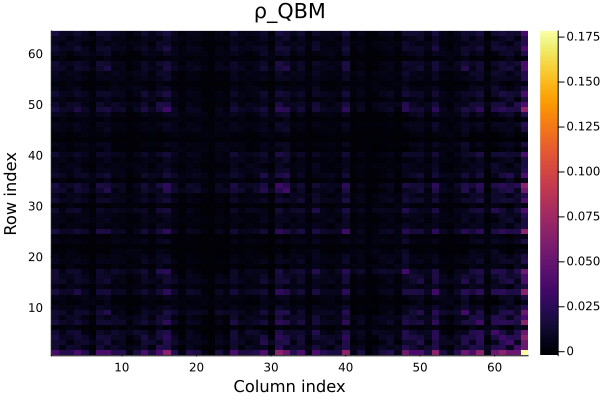

In [16]:
heatmap(reverse(real(rho_qbm_matrix); dims=1),
        xlabel="Column index",
        ylabel="Row index",
        title="ρ_QBM"
        )

## Training of the QBM


In [24]:
target_probs_beta1 = computesymmetriceigenvalues(target_eta_beta1_matrix)
target_probs_beta1 = clamp.(target_probs_beta1, 1e-300, Inf);

target_probs_beta2 = computesymmetriceigenvalues(target_eta_beta2_matrix)
target_probs_beta2 = clamp.(target_probs_beta2, 1e-300, Inf);

target_probs_beta∞ = computesymmetriceigenvalues(target_eta_beta∞_matrix)
target_probs_beta∞ = clamp.(target_probs_beta∞ , 1e-300, Inf);

In [22]:
params = HamiltonianParams(n; wi_xyz=b, wij_xyz=j)
# learning rate
gamma = 0.2
# number of epochs
epochs = 2000

# stop when gradient is smaller than epsilon, at the final number of epochs
epsilon = 1e-6
# keep track of loss and gradients
qre_hist = Float64[]
grad_hist = Vector{Float64}[]

for epoch in 1:epochs
    qbm_xyz = makehamiltonian(params)
    qbm_xyz_matrix = paulistringtomatrix(qbm_xyz)
    push!(qre_hist, computequantumrelativeentropy(target_eta_beta1_matrix, target_probs_beta1,     qbm_xyz_matrix))

    # create qbm state
    circuit, theta = paulistringtocircuit(qbm_xyz)
    num_layers = 100
    beta = 1.
    max_weight = n
    min_abs_coeff = 1e-10
    rho = makethermalstate(n, circuit, theta, num_layers;
                                    beta=beta, max_weight=max_weight,
                                    min_abs_coeff=min_abs_coeff)
    rho_matrix = paulistringtomatrix(rho)

    # Compute and record gradient
    grads = computegradients(params, target_eta_beta1, rho)
    flat_grads = vcat(
        reduce(vcat, grads.wi_xyz)...,
        reduce(vcat, [vec(g) for g in grads.wij_xyz])...
    )
    push!(grad_hist, abs.(flat_grads))

    # Update parameters
    updateparameters!(params, grads, gamma)

    # Print diagnostics
    if epoch % 100 == 0
        @printf("\nEpoch %d\n", epoch)
        @printf("  Quantum relative entropy: %.6f\n", qre_hist[end])
        @printf("  Max abs gradient:         %.6f\n", maximum(grad_hist[end]))
    end

    # Stop if converged
    if maximum(grad_hist[end]) < epsilon
        println("Converged: max gradient < epsilon")
        break
    end
end


Epoch 100
  Quantum relative entropy: 1.252097
  Max abs gradient:         0.081551

Epoch 200
  Quantum relative entropy: 0.862960
  Max abs gradient:         0.044086

Epoch 300
  Quantum relative entropy: 0.736592
  Max abs gradient:         0.029479

Epoch 400
  Quantum relative entropy: 0.677496
  Max abs gradient:         0.021455

Epoch 500
  Quantum relative entropy: 0.644422
  Max abs gradient:         0.016449

Epoch 600
  Quantum relative entropy: 0.623601
  Max abs gradient:         0.013111

Epoch 700
  Quantum relative entropy: 0.609355
  Max abs gradient:         0.010779

Epoch 800
  Quantum relative entropy: 0.599009
  Max abs gradient:         0.009086

Epoch 900
  Quantum relative entropy: 0.591164
  Max abs gradient:         0.007816

Epoch 1000
  Quantum relative entropy: 0.585025
  Max abs gradient:         0.006836

Epoch 1100
  Quantum relative entropy: 0.580107
  Max abs gradient:         0.006059

Epoch 1200
  Quantum relative entropy: 0.576096
  Max abs grad

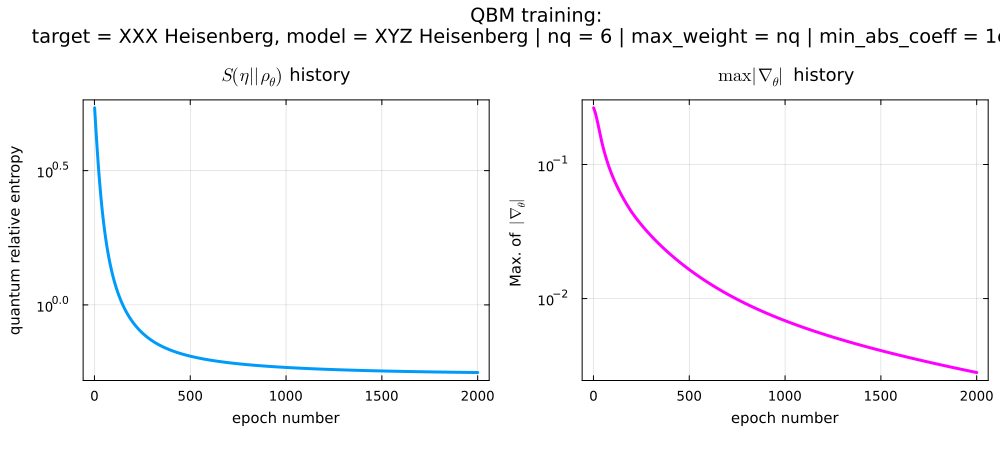

In [23]:
gr()

# ---- First plot ----
p1 = plot(qre_hist,
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = false,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Second plot ----
p2 = plot([maximum(g) for g in grad_hist],
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),  
    legend = false,
    color = :fuchsia,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Combine side by side ----
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training:\ntarget = XXX Heisenberg, model = XYZ Heisenberg | nq = 6 | max_weight = nq | min_abs_coeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm       
)

display(combined)

In [28]:
params = HamiltonianParams(n; wi_xyz=b, wij_xyz=j)
# learning rate
gamma = 0.2
# number of epochs
epochs = 2000

# stop when gradient is smaller than epsilon, at the final number of epochs
epsilon = 1e-6
# keep track of loss and gradients
qre_hist = Float64[]
grad_hist = Vector{Float64}[]

for epoch in 1:epochs
    qbm_xyz = makehamiltonian(params)
    qbm_xyz_matrix = paulistringtomatrix(qbm_xyz)
    push!(qre_hist, computequantumrelativeentropy(target_eta_beta2_matrix, target_probs_beta2, qbm_xyz_matrix))

    # create qbm state
    circuit, theta = paulistringtocircuit(qbm_xyz)
    num_layers = 100
    beta = 1.
    max_weight = 4
    min_abs_coeff = 2^-10
    rho = makethermalstate(n, circuit, theta, num_layers;
                                    beta=beta, max_weight=max_weight,
                                    min_abs_coeff=min_abs_coeff)
    rho_matrix = paulistringtomatrix(rho)

    # Compute and record gradient
    grads = computegradients(params, target_eta_beta1, rho)
    flat_grads = vcat(
        reduce(vcat, grads.wi_xyz)...,
        reduce(vcat, [vec(g) for g in grads.wij_xyz])...
    )
    push!(grad_hist, abs.(flat_grads))

    # Update parameters
    updateparameters!(params, grads, gamma)

    # Print diagnostics
    if epoch % 100 == 0
        @printf("\nEpoch %d\n", epoch)
        @printf("  Quantum relative entropy: %.6f\n", qre_hist[end])
        @printf("  Max abs gradient:         %.6f\n", maximum(grad_hist[end]))
    end

    # Stop if converged
    if maximum(grad_hist[end]) < epsilon
        println("Converged: max gradient < epsilon")
        break
    end
end


Epoch 100
  Quantum relative entropy: 1.663686
  Max abs gradient:         0.090146

Epoch 200
  Quantum relative entropy: 1.193160
  Max abs gradient:         0.050099

Epoch 300
  Quantum relative entropy: 1.036007
  Max abs gradient:         0.034776

Epoch 400
  Quantum relative entropy: 0.955642
  Max abs gradient:         0.026493

Epoch 500
  Quantum relative entropy: 0.905822
  Max abs gradient:         0.021488

Epoch 600
  Quantum relative entropy: 0.871445
  Max abs gradient:         0.018196

Epoch 700
  Quantum relative entropy: 0.846128
  Max abs gradient:         0.015857

Epoch 800
  Quantum relative entropy: 0.826904
  Max abs gradient:         0.014072

Epoch 900
  Quantum relative entropy: 0.811637
  Max abs gradient:         0.012789

Epoch 1000
  Quantum relative entropy: 0.799742
  Max abs gradient:         0.011719

Epoch 1100
  Quantum relative entropy: 0.789659
  Max abs gradient:         0.010945

Epoch 1200
  Quantum relative entropy: 0.782222
  Max abs grad

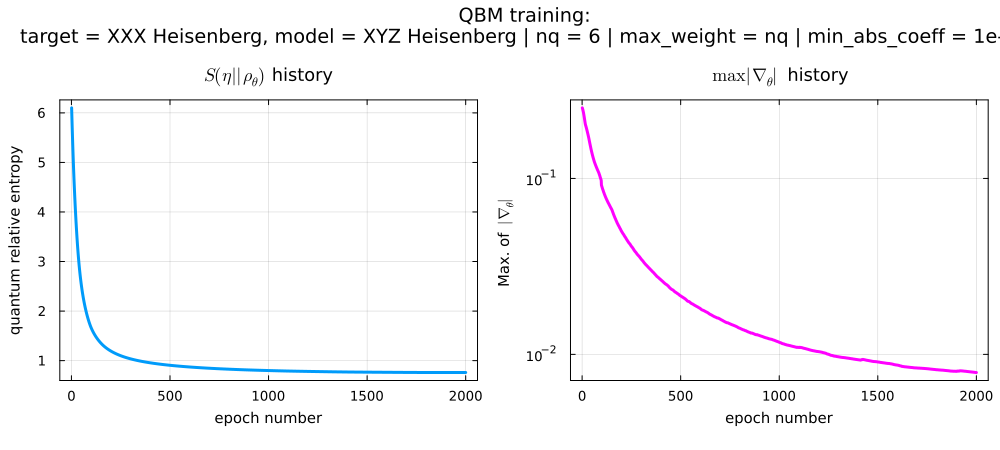

In [30]:
gr()

# ---- First plot ----
p1 = plot(qre_hist,
    # yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = false,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Second plot ----
p2 = plot([maximum(g) for g in grad_hist],
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),  
    legend = false,
    color = :fuchsia,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Combine side by side ----
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training:\ntarget = XXX Heisenberg, model = XYZ Heisenberg | nq = 6 | max_weight = nq | min_abs_coeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm       
)

display(combined)